Загрузка данных...
Загружено строк: 10000
Выбраны необходимые столбцы.
Удалено строк с пропусками: 1552. Осталось: 3448
Удалено строк с выбросами: 716. Осталось: 2732


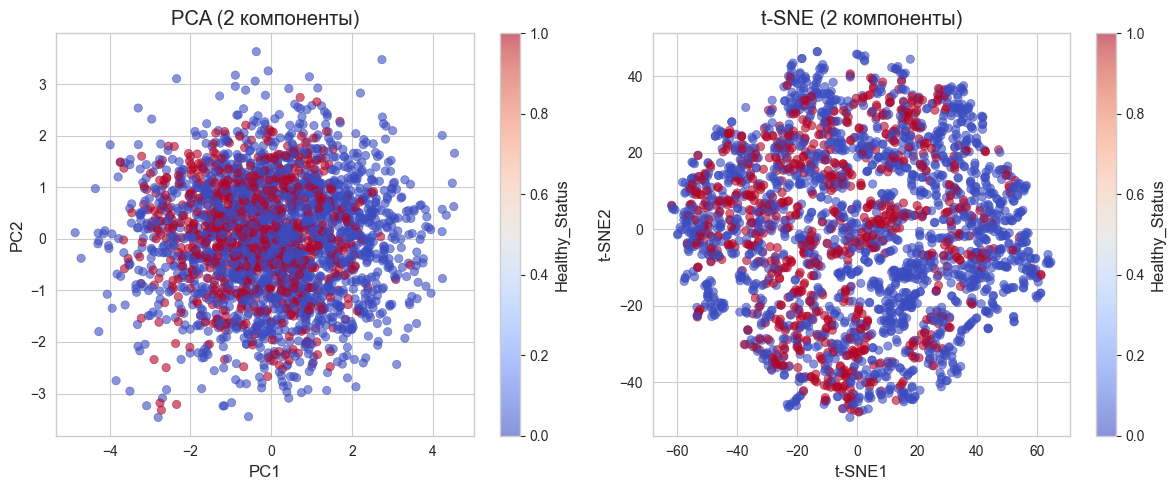

PyCaret не установлен. Используем GridSearchCV с несколькими моделями.

Лучшая модель по CV F1: RF (score=0.6164)

Матрица ошибок:
[[305  68]
 [ 58 116]]
F1-мера: 0.6480
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       373
           1       0.63      0.67      0.65       174

    accuracy                           0.77       547
   macro avg       0.74      0.74      0.74       547
weighted avg       0.77      0.77      0.77       547



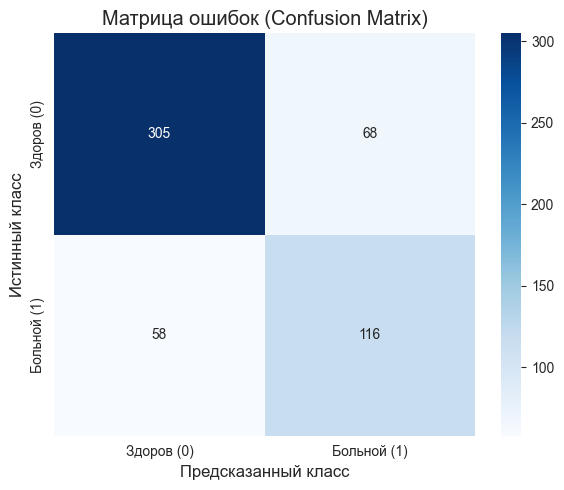

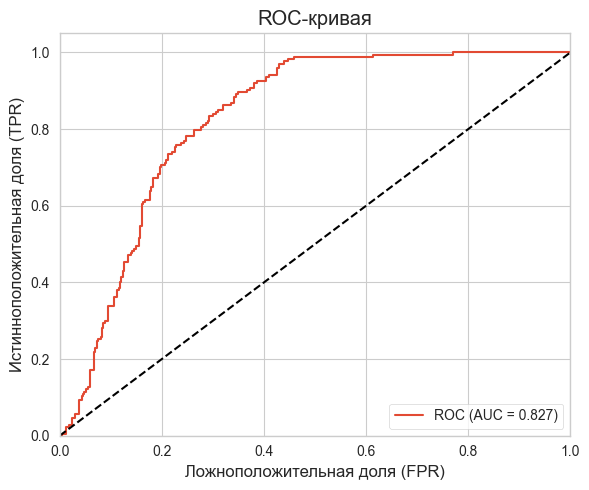

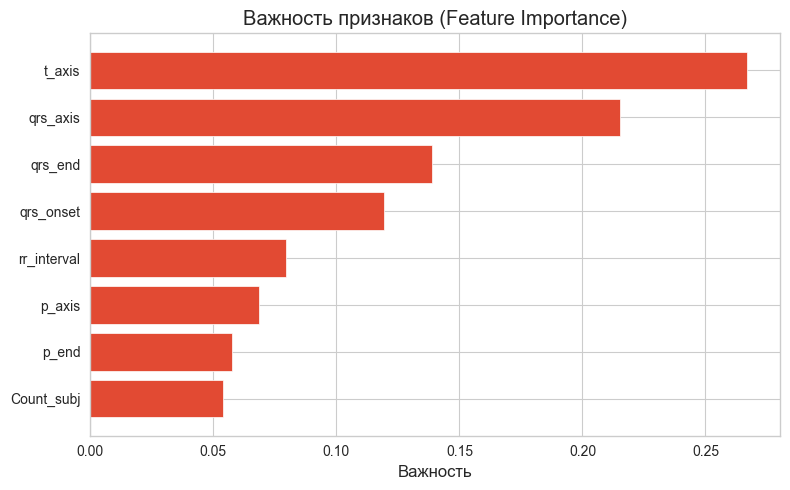

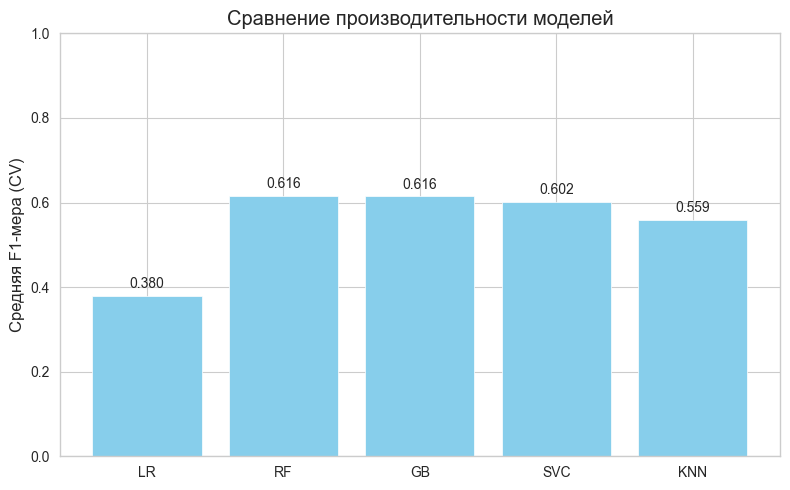


Анализ завершён. Все графики сохранены в текущую директорию.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, f1_score, classification_report, roc_curve, auc, RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('ggplot')
sns.set_style('whitegrid')

# -------------------------------
# 1. Загрузка данных (первые 5000 строк)
# -------------------------------
print("Загрузка данных...")
# Чтение файла data.txt (разделитель запятая)
current_dir = Path().absolute()          # مجلد النوت بوك الحالي
data_path = current_dir / 'data.txt'

# تحقق من وجود الملف
if data_path.exists():
    df = pd.read_csv(data_path, sep=',', dtype=str, engine='python')
    print(f"تم تحميل {len(df)} سطر بنجاح من {data_path}")
else:
    print(f"الملف غير موجود في المسار: {data_path}")


print(f"Загружено строк: {len(df)}")

# Берём первые 5000 строк
df = df.head(5000).copy()

# -------------------------------
# 2. Выбор нужных столбцов
# -------------------------------
required_cols = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end',
                 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']
df = df[required_cols].copy()
print("Выбраны необходимые столбцы.")

# -------------------------------
# 3. Предобработка данных
# -------------------------------
# Заменяем значения 29999 (маркер пропуска) на NaN
df.replace('29999', np.nan, inplace=True)
# Принудительно преобразуем в числовые
for col in required_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Удаляем строки с NaN
initial_rows = len(df)
df.dropna(inplace=True)
print(f"Удалено строк с пропусками: {initial_rows - len(df)}. Осталось: {len(df)}")

# Удаление выбросов по IQR
features = required_cols[:-1]  # все кроме Healthy_Status
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_mask = ((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)
df = df[~outlier_mask]
print(f"Удалено строк с выбросами: {outlier_mask.sum()}. Осталось: {len(df)}")

# Разделение на признаки и целевую переменную
X = df[features]
y = df['Healthy_Status'].astype(int)

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 4. PCA и t-SNE визуализация (как в отчёте)
# -------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
scatter1 = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.6)
plt.title('PCA (2 компоненты)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter1, label='Healthy_Status')

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)
plt.subplot(1,2,2)
scatter2 = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='coolwarm', alpha=0.6)
plt.title('t-SNE (2 компоненты)')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.colorbar(scatter2, label='Healthy_Status')
plt.tight_layout()
plt.savefig('pca_tsne_plot.png', dpi=150)
plt.show()

# -------------------------------
# 5. AutoML и оценка модели
# -------------------------------
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Попробуем использовать PyCaret, если установлен
best_model = None
try:
    from pycaret.classification import setup, compare_models, finalize_model, predict_model
    # Подготовка данных для PyCaret
    data = X.copy()
    data['Healthy_Status'] = y
    train_data, test_data = train_test_split(data, test_size=0.2, random_state=42, stratify=y)
    
    clf_setup = setup(data=train_data, target='Healthy_Status',
                      session_id=123, normalize=True,
                      remove_multicollinearity=True,
                      fold_strategy='kfold', fold=5,
                      silent=True, verbose=False)
    best_model = compare_models(sort='F1', fold=5, verbose=True)
    final_model = finalize_model(best_model)
    predictions = predict_model(final_model, data=test_data)
    y_pred = predictions['prediction_label'].values
    y_true = test_data['Healthy_Status'].values
    
except ImportError:
    print("PyCaret не установлен. Используем GridSearchCV с несколькими моделями.")
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.svm import SVC
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.model_selection import GridSearchCV
    
    models = {
        'LR': LogisticRegression(max_iter=1000),
        'RF': RandomForestClassifier(random_state=42),
        'GB': GradientBoostingClassifier(random_state=42),
        'SVC': SVC(probability=True),
        'KNN': KNeighborsClassifier()
    }
    param_grids = {
        'LR': {'C': [0.1, 1.0, 10.0]},
        'RF': {'n_estimators': [50, 100], 'max_depth': [5, 10, None]},
        'GB': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]},
        'SVC': {'C': [0.1, 1.0, 10.0], 'gamma': ['scale', 'auto']},
        'KNN': {'n_neighbors': [3, 5, 7]}
    }
    best_score = -1
    best_model = None
    best_name = ""
    cv_results = []
    for name, model in models.items():
        grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1', n_jobs=-1)
        grid.fit(X_train, y_train)
        cv_results.append((name, grid.best_score_, grid.best_estimator_))
        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            best_model = grid.best_estimator_
            best_name = name
    print(f"\nЛучшая модель по CV F1: {best_name} (score={best_score:.4f})")
    y_pred = best_model.predict(X_test)
    y_true = y_test
    # Для ROC нужно probability, если модель поддерживает
    if hasattr(best_model, "predict_proba"):
        y_pred_proba = best_model.predict_proba(X_test)[:,1]
    else:
        y_pred_proba = None

# -------------------------------
# 6. Оценка качества модели и визуализация
# -------------------------------
cm = confusion_matrix(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f"\nМатрица ошибок:\n{cm}")
print(f"F1-мера: {f1:.4f}")
print(classification_report(y_true, y_pred))

# --- График 1: Тепловая карта матрицы ошибок (русские подписи) ---
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Здоров (0)', 'Больной (1)'],
            yticklabels=['Здоров (0)', 'Больной (1)'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# --- График 2: ROC-кривая (если доступны вероятности) ---
if 'y_pred_proba' in locals() and y_pred_proba is not None:
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Ложноположительная доля (FPR)')
    plt.ylabel('Истинноположительная доля (TPR)')
    plt.title('ROC-кривая')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150)
    plt.show()
else:
    # Если модель не даёт вероятностей, можно использовать SVC с probability=True или другой метод
    print("ROC-кривая не может быть построена - модель не выдаёт вероятности.")

# --- График 3: Важность признаков (для моделей, поддерживающих feature_importances_) ---
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(8,5))
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Важность')
    plt.title('Важность признаков (Feature Importance)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()
else:
    print("Модель не поддерживает вывод важности признаков.")

# --- График 4: Сравнение моделей (если использовался GridSearchCV) ---
if 'cv_results' in locals() and cv_results:
    names = [r[0] for r in cv_results]
    scores = [r[1] for r in cv_results]
    plt.figure(figsize=(8,5))
    bars = plt.bar(names, scores, color='skyblue')
    plt.ylim(0, 1)
    plt.ylabel('Средняя F1-мера (CV)')
    plt.title('Сравнение производительности моделей')
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig('models_comparison.png', dpi=150)
    plt.show()

print("\nАнализ завершён. Все графики сохранены в текущую директорию.")